#Scraper

In [6]:
import requests
from bs4 import BeautifulSoup

In [7]:
r=requests.get('https://www.property.com.mm/index.php/en')
c=r.content
c

b'<!DOCTYPE html>\n<html lang="en">\n  <head>  \n        <meta charset="utf-8">\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\n    <meta name="viewport" content="width=device-width, initial-scale=1">  \n    <title>Property.com.mm | Buy, Sell, Rent, Lease - Homepage - Find Commercial Industrial Residential Real Estate Property House Condo Land Warehouse Factory in Yangon Myanmar</title>\n    <!-- Autocomplete css -->\n    <!-- <link rel="stylesheet" href="//code.jquery.com/ui/1.13.2/themes/base/jquery-ui.css"> -->\n    <meta name="description" content="Property.com.mm makes your home searching in Myanmar a pleasant and expedited experience with thousands of listings with PICTURES and hundreds of agents in Yangon. Please call us now +95-09-440048448." />\n    <meta name="keywords" content="Property.com.mm" />\n    <meta name="author" content="" />\n\t<!-- <meta name="apple-itunes-app" content="app-id=544007664"> -->\n    <meta name="google-play-app" content="app-id=com.studi

In [4]:
soup=BeautifulSoup(c,'html.parser')
print(soup.prettify)

<bound method Tag.prettify of <!DOCTYPE html>

<html lang="en">
<head>
<meta charset="utf-8"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<title>Property.com.mm | Buy, Sell, Rent, Lease - Homepage - Find Commercial Industrial Residential Real Estate Property House Condo Land Warehouse Factory in Yangon Myanmar</title>
<!-- Autocomplete css -->
<!-- <link rel="stylesheet" href="//code.jquery.com/ui/1.13.2/themes/base/jquery-ui.css"> -->
<meta content="Property.com.mm makes your home searching in Myanmar a pleasant and expedited experience with thousands of listings with PICTURES and hundreds of agents in Yangon. Please call us now +95-09-440048448." name="description">
<meta content="Property.com.mm" name="keywords">
<meta content="" name="author">
<!-- <meta name="apple-itunes-app" content="app-id=544007664"> -->
<meta content="app-id=com.studioamk.pmm" name="google-play-app"/>
<meta content="https://www.

In [32]:
# all=soup.find_all("div",{"class":"cl-gallery"})
all = soup.find_all("article", class_="aa-properties-item")




In [33]:
all

[<article class="aa-properties-item aa-single-property">
 <div class="properties-img-height">
 <a "="" class="aa-properties-item-img" href="https://property.com.mm/index.php/property/5821/en/a_great_opportunity_for_those_who_want_to_live_in_a_luxury_house_near_inya_lake" title="A great opportunity for those who want to live in a luxury house near Inya Lake. in Mayangone, Yangon">
 <img alt="Features" src="https://property.com.mm/files/thumbnail/photo_2026_03_31_16_35_192026_03_3112_22_15.jpg"/>
 </a>
 </div>
 <div class="aa-tag for-sale">
                     Rent                  </div>
 <div class="cc-tag available">
                     available                  </div>
 <div class="aa-properties-item-content">
 <div class="row properties-content-height">
 <div class="col-md-12" style="height:45px;overflow:hidden;margin:10px 5px;">
 <p class="displayaddress"><strong title="A great opportunity for those who want to live in a luxury house near Inya Lake. in Mayangone, Yangon">A great 

In [34]:
len(all)

9

In [16]:
all[0].find_all("p",{"class":"displayaddress"})

[<p class="displayaddress"><strong title="A great opportunity for those who want to live in a luxury house near Inya Lake. in Mayangone, Yangon">A great opportunity for those who want to live in a luxury house near Inya Lake. in Mayangone, Yangon</strong>
 </p>,
 <p class="displayaddress"><strong title="House for rent on 8 miles of country road, suitable for family living and also suitable for opening a business office. in Mayangone, Yangon">House for rent on 8 miles of country road, suitable for family living and also suitable for opening a business office. in Mayangone, Yangon</strong>
 </p>,
 <p class="displayaddress"><strong title="Between Merchant Street and Mahabandula Road  Suitable for business, ready for sale in Kyauktada, Yangon">Between Merchant Street and Mahabandula Road  Suitable for business, ready for sale in Kyauktada, Yangon</strong>
 </p>,
 <p class="displayaddress"><strong title="For sale between 13th and Monk Street, very convenient for business. in Lanmadaw, Yango

In [27]:
all[0].find("p",{"class":"displayaddress"}).text.replace("\n","")

'Flat For Rent in Thamain Bayan Road, Tamwe, Yangon'

In [51]:
all[2].find("span",{'class','aa-price'}).text

'50 Lkhs'

In [77]:
all[2].find("p",{'class','featured-option_2'}).text

'Landed House'

In [72]:
print(item.prettify())

<article class="aa-properties-item aa-single-property">
 <a class="aa-properties-item-img" href="https://www.property.com.mm/index.php/property/5723/en/flat_for_rent" title="latest properties">
  <img alt="Features" src="https://www.property.com.mm/files/thumbnail/8f14e45fceea167a5a36dedd4bea252024_01_3109_32_52.jpg"/>
 </a>
 <div class="aa-tag for-sale">
  Sale
 </div>
 <div class="bb-tag available">
  available
 </div>
 <div class="aa-properties-item-content">
  <div class="row" style="margin-top:5px;">
   <div class="col-md-6">
    <p class="featured-option_2">
     New Flat
    </p>
   </div>
   <div class="col-md-6">
    <p class="featured-option_127">
     500 sqft
    </p>
   </div>
  </div>
  <div class="aa-properties-info">
   <div class="row icon-wrapper">
    <div class="col-md-6">
     <span>
      1
      <img alt="Total Rooms" src="https://www.property.com.mm/templates/bootstrap2-responsive/assets/img/room_ico.png" style="transform: perspective(2000px);" title="Total Room

In [8]:
l=[]
base_url="https://property.com.mm/index.php/en/6/browse"
for page in range(0,60,10):
  url=base_url+str(page)
  print("Scraping:",url)

  r=requests.get(url)
  c=r.content
  soup=BeautifulSoup(c,"html.parser")

  all=soup.find_all("article", class_="aa-properties-item")
  print("Listings on this page:",len(all))

  for item in all:
    d={}
    try:
         price_tag = item.find("span", class_="aa-price")
         d["Price"] = price_tag.text.strip() if price_tag else "N/A"

         address_tag = item.find("p", class_="displayaddress")
         d["Address"] = address_tag.text.strip() if address_tag else "N/A"

         type_tag = item.find("p", class_="featured-option_2")
         d["Type"] = type_tag.text.strip() if type_tag else "N/A"


         room_icon=item.find("img",alt="Total Rooms")
         d['Rooms']=room_icon.parent.text.strip() if room_icon else "0"

         bed_icon = item.find("img", alt="Total Bedrooms")
         d["Bedrooms"] = bed_icon.parent.text.strip() if bed_icon else "0"


         l.append(d)
    except Exception as e:
      continue

  print(f"Total Listing collected:{len(l)}")


Scraping: https://property.com.mm/index.php/en/6/browse0
Listings on this page: 9
Total Listing collected:9
Scraping: https://property.com.mm/index.php/en/6/browse10
Listings on this page: 9
Total Listing collected:18
Scraping: https://property.com.mm/index.php/en/6/browse20
Listings on this page: 9
Total Listing collected:27
Scraping: https://property.com.mm/index.php/en/6/browse30
Listings on this page: 9
Total Listing collected:36
Scraping: https://property.com.mm/index.php/en/6/browse40
Listings on this page: 9
Total Listing collected:45
Scraping: https://property.com.mm/index.php/en/6/browse50
Listings on this page: 9
Total Listing collected:54


In [9]:
import pandas
df=pandas.DataFrame(l)

In [10]:
df


,Price,Address,Type,Rooms,Bedrooms
0,USD 5500 |,A great opportunity for those who want to live...,Landed House,4,0
1,40 Lkhs |,"House for rent on 8 miles of country road, sui...",Landed House,5,0
2,20000 Lkhs |,Between Merchant Street and Mahabandula Road ...,Flat,0,0
3,20000 Lkhs |,"For sale between 13th and Monk Street, very co...",Flat,0,0
4,80 Lkhs |,"House for rent near Moe Kaung Road, ideal for ...",Landed House,7,0
5,40 Lkhs |,The Lake Suite Condo for rent on Kamaba Aye Pa...,Flat,3,2
6,40000 Lkhs |,"Near U Wisara Road, North Dagon Township in Da...",Landed House,20,0
7,40000 Lkhs |,"Bahan Township, U Wisara Road in Bahan, Yangon",Landed House,16,0
8,39800 Lkhs |,Land for sale with building ready for Hotel / ...,Landed House,16,0
9,USD 5500 |,A great opportunity for those who want to live...,Landed House,4,0


In [11]:
base_url="https://property.com.mm/index.php/en/6/browse"
for page in range(0,60,10):
  print(base_url+str(page))
  # r=requests.get(base_url+str(page))
  # c=r.content
  # soup=BeautifulSoup(c,"html.parser")
  # print(soup.prettify)

https://property.com.mm/index.php/en/6/browse0
https://property.com.mm/index.php/en/6/browse10
https://property.com.mm/index.php/en/6/browse20
https://property.com.mm/index.php/en/6/browse30
https://property.com.mm/index.php/en/6/browse40
https://property.com.mm/index.php/en/6/browse50


In [12]:
df.to_csv("output.csv")

In [13]:
import pandas as pd
df=pd.read_csv("output.csv")
df.head()

,Unnamed: 0,Price,Address,Type,Rooms,Bedrooms
0,0,USD 5500 |,A great opportunity for those who want to live...,Landed House,4,0
1,1,40 Lkhs |,"House for rent on 8 miles of country road, sui...",Landed House,5,0
2,2,20000 Lkhs |,Between Merchant Street and Mahabandula Road ...,Flat,0,0
3,3,20000 Lkhs |,"For sale between 13th and Monk Street, very co...",Flat,0,0
4,4,80 Lkhs |,"House for rent near Moe Kaung Road, ideal for ...",Landed House,7,0


#Clean Data

In [14]:
import pandas as pd
import re

def parse_price(price):
    if pd.isna(price):
        return pd.Series([None, None])

    price = str(price).replace("|", "").strip()

    if "USD" in price:
        currency = "USD"
        number = re.findall(r"\d+(?:\.\d+)?", price)
        value = float(number[0]) if number else None

    elif "Lkhs" in price:
        currency = "Lkhs"
        number = re.findall(r"\d+(?:\.\d+)?", price)
        value = float(number[0]) if number else None

    else:
        currency = "Unknown"
        number = re.findall(r"\d+(?:\.\d+)?", price)
        value = float(number[0]) if number else None

    return pd.Series([currency, value])

df[["Currency", "Price_Value"]] = df["Price"].apply(parse_price)

In [15]:
print(df[["Price", "Currency", "Price_Value"]].head())

          Price Currency  Price_Value
0    USD 5500 |      USD       5500.0
1     40 Lkhs |     Lkhs         40.0
2  20000 Lkhs |     Lkhs      20000.0
3  20000 Lkhs |     Lkhs      20000.0
4     80 Lkhs |     Lkhs         80.0


## Currency

In [16]:
# Step 1: Clean raw string
df["Price_Clean"] = df["Price"].astype(str).str.replace("|", "", regex=False).str.strip()

# Step 2: Extract currency FIRST
df["Currency"] = df["Price_Clean"].apply(
    lambda x: "USD" if "USD" in str(x)
    else "Lkhs" if "Lkhs" in str(x)
    else "Unknown"
)

# Step 3: Extract numeric value
df["Price_Value"] = df["Price_Clean"].str.extract(r"(\d+(?:\.\d+)?)").astype(float)

In [53]:
print(df["Price"].head())
print(df["Price"].dtype)

0      192.5
1       40.0
2    20000.0
3    20000.0
4       80.0
Name: Price, dtype: float64
float64


In [17]:
df = pd.read_csv("output.csv")

In [18]:
import pandas as pd

df = pd.read_csv("output.csv")

df["Price_Raw"] = df["Price"].astype(str)
df["Price_Clean"] = df["Price_Raw"].str.replace("|", "", regex=False).str.strip()

df["Currency"] = df["Price_Clean"].apply(
    lambda x: "USD" if "USD" in x
    else "Lkhs" if "Lkhs" in x
    else "Unknown"
)

df["Price_Value"] = df["Price_Clean"].str.extract(r"(\d+(?:\.\d+)?)").astype(float)

print(df[["Price", "Price_Clean", "Currency", "Price_Value"]].head())

          Price Price_Clean Currency  Price_Value
0    USD 5500 |    USD 5500      USD       5500.0
1     40 Lkhs |     40 Lkhs     Lkhs         40.0
2  20000 Lkhs |  20000 Lkhs     Lkhs      20000.0
3  20000 Lkhs |  20000 Lkhs     Lkhs      20000.0
4     80 Lkhs |     80 Lkhs     Lkhs         80.0


## Convert to One Currency

In [19]:
import numpy as np
USD_TO_LKHS = 2100 / 100000  # example: convert USD → Lkhs (adjust if needed)

df["Price_Lkhs"] = np.where(
    df["Currency"] == "USD",
    df["Price_Value"] * USD_TO_LKHS,
    df["Price_Value"]
)

##Check data quality

In [56]:
print(df.info())
print(df.isnull().sum())
print(df["Currency"].value_counts())
print(df["Type"].value_counts())
print(df["Bedrooms"].value_counts())
print(df["Rooms"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0.1   54 non-null     int64  
 1   Unnamed: 0     54 non-null     int64  
 2   Price          54 non-null     object 
 3   Address        54 non-null     object 
 4   Type           54 non-null     object 
 5   Rooms          54 non-null     int64  
 6   Bedrooms       54 non-null     int64  
 7   Price_Numeric  54 non-null     float64
 8   Price_Raw      54 non-null     object 
 9   Price_Clean    54 non-null     object 
 10  Currency       54 non-null     object 
 11  Price_Value    54 non-null     float64
dtypes: float64(2), int64(4), object(6)
memory usage: 5.2+ KB
None
Unnamed: 0.1     0
Unnamed: 0       0
Price            0
Address          0
Type             0
Rooms            0
Bedrooms         0
Price_Numeric    0
Price_Raw        0
Price_Clean      0
Currency         0
Price

In [57]:
df[df["Price_Value"].isnull()]
df[df["Bedrooms"] == 0].head(10)

,Unnamed: 0.1,Unnamed: 0,Price,Address,Type,Rooms,Bedrooms,Price_Numeric,Price_Raw,Price_Clean,Currency,Price_Value
0,0,0,USD 5500 |,A great opportunity for those who want to live...,Landed House,4,0,1.925000e+07,USD 5500 |,USD 5500,USD,5500.0
1,1,1,40 Lkhs |,"House for rent on 8 miles of country road, sui...",Landed House,5,0,4.000000e+06,40 Lkhs |,40 Lkhs,Lkhs,40.0
2,2,2,20000 Lkhs |,Between Merchant Street and Mahabandula Road ...,Flat,0,0,2.000000e+09,20000 Lkhs |,20000 Lkhs,Lkhs,20000.0
3,3,3,20000 Lkhs |,"For sale between 13th and Monk Street, very co...",Flat,0,0,2.000000e+09,20000 Lkhs |,20000 Lkhs,Lkhs,20000.0
4,4,4,80 Lkhs |,"House for rent near Moe Kaung Road, ideal for ...",Landed House,7,0,8.000000e+06,80 Lkhs |,80 Lkhs,Lkhs,80.0
6,6,6,40000 Lkhs |,"Near U Wisara Road, North Dagon Township in Da...",Landed House,20,0,4.000000e+09,40000 Lkhs |,40000 Lkhs,Lkhs,40000.0
7,7,7,40000 Lkhs |,"Bahan Township, U Wisara Road in Bahan, Yangon",Landed House,16,0,4.000000e+09,40000 Lkhs |,40000 Lkhs,Lkhs,40000.0
8,8,8,39800 Lkhs |,Land for sale with building ready for Hotel / ...,Landed House,16,0,3.980000e+09,39800 Lkhs |,39800 Lkhs,Lkhs,39800.0
9,9,9,USD 5500 |,A great opportunity for those who want to live...,Landed House,4,0,1.925000e+07,USD 5500 |,USD 5500,USD,5500.0
10,10,10,40 Lkhs |,"House for rent on 8 miles of country road, sui...",Landed House,5,0,4.000000e+06,40 Lkhs |,40 Lkhs,Lkhs,40.0


In [58]:
df_usd = df[df["Currency"] == "USD"].copy()
df_lkhs = df[df["Currency"] == "Lkhs"].copy()

In [59]:
print(df_usd[["Price", "Price_Value"]].head())
print(df_lkhs[["Price", "Price_Value"]].head())

         Price  Price_Value
0   USD 5500 |       5500.0
9   USD 5500 |       5500.0
18  USD 5500 |       5500.0
27  USD 5500 |       5500.0
36  USD 5500 |       5500.0
          Price  Price_Value
1     40 Lkhs |         40.0
2  20000 Lkhs |      20000.0
3  20000 Lkhs |      20000.0
4     80 Lkhs |         80.0
5     40 Lkhs |         40.0


##clean Rooms and Bedrooms

In [20]:
df["Rooms"] = pd.to_numeric(df["Rooms"], errors="coerce")
df["Bedrooms"] = pd.to_numeric(df["Bedrooms"], errors="coerce")

Handle Missing

In [21]:
df["Rooms"].fillna(df["Rooms"].median(), inplace=True)
df["Bedrooms"].fillna(df["Bedrooms"].median(), inplace=True)

/tmp/ipykernel_1384/1733572831.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Rooms"].fillna(df["Rooms"].median(), inplace=True)
/tmp/ipykernel_1384/1733572831.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [22]:
print(df[["Rooms", "Bedrooms"]].describe())

           Rooms   Bedrooms
count  54.000000  54.000000
mean    7.888889   0.222222
std     7.144510   0.634441
min     0.000000   0.000000
25%     3.000000   0.000000
50%     5.000000   0.000000
75%    16.000000   0.000000
max    20.000000   2.000000


## Clean Categorical columns

In [23]:
df["Type"] = df["Type"].str.strip().fillna("Unknown")

In [24]:
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

Remove Useless columns

In [25]:
df_clean = df[[
    "Price_Lkhs",
    "Rooms",
    "Bedrooms"
] + [col for col in df.columns if col.startswith("Type_")]]

Handle Outliers for ML

In [26]:
df_clean = df_clean[df_clean["Price_Lkhs"] < df_clean["Price_Lkhs"].quantile(0.99)]

In [29]:
for col in df_clean.columns:
    if df_clean[col].dtype == 'bool':
        df_clean[col] = df_clean[col].astype(int)

Final Check

In [30]:
print(df_clean.info())
print(df_clean.describe())
print(df_clean.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 0 to 53
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price_Lkhs         42 non-null     float64
 1   Rooms              42 non-null     int64  
 2   Bedrooms           42 non-null     int64  
 3   Type_Landed House  42 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 1.6 KB
None
         Price_Lkhs      Rooms   Bedrooms  Type_Landed House
count     42.000000  42.000000  42.000000          42.000000
mean   11439.357143   5.000000   0.285714           0.571429
std    14657.308328   5.132394   0.708338           0.500870
min       40.000000   0.000000   0.000000           0.000000
25%       40.000000   0.000000   0.000000           0.000000
50%      115.500000   4.000000   0.000000           1.000000
75%    20000.000000   7.000000   0.000000           1.000000
max    39800.000000  16.000000   2.000000           1.000000
Price_Lkhs 

In [31]:
df_clean.to_csv("ml_ready_properties.csv", index=False)

# Train Model

## 1. Prepare Features (X) and target(y)

In [36]:
from sklearn.model_selection import train_test_split

#Feature
X = df_clean.drop("Price_Lkhs", axis=1)

#Target
y = df_clean["Price_Lkhs"]




##2. Train-Test split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##3.Train Model

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

##4< Make Prediction

In [39]:
y_pred = model.predict(X_test)

##5. Evaluation Model

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 2692.434037530021
MSE: 18332942.99314584
R2 Score: 0.8956639294637725


##6. Visualize prediction

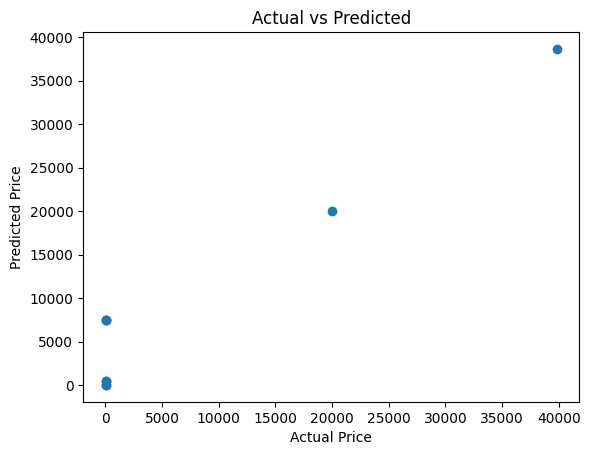

In [41]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [42]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(feature_importance.sort_values(by="Coefficient", ascending=False))

             Feature   Coefficient
0              Rooms   3467.218342
1           Bedrooms -15180.827513
2  Type_Landed House -36814.092197


In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.9998490795395603


Tne results look so wrong, seems like model learned unstable relationship due to limited features and data. Cause the dataset lacks important variable of Location, sqft, Floor and City area...etc.

In [47]:
print(X.columns)
#Check featurees and make sure no price columns

Index(['Rooms', 'Bedrooms', 'Type_Landed House'], dtype='object')


In [46]:
print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))

#compare train vs test score

Train R2: 0.9998635800116814
Test R2: 0.9998490795395603


In [48]:
#Shuffle test
import numpy as np
np.random.shuffle(y_test.values)
print("After shuffle:", rf.score(X_test, y_test))

After shuffle: -1.4712115547653082


After shuffled y_test, it means destroyed the relationship between features and target which tells my model is not cheating, it actually learning patterns and no obvious data leakage.

In [49]:
print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))

Train R2: 0.9998635800116814
Test R2: -1.4712115547653082


In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=3,        # limit tree depth
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))

Train R2: 0.971151256756838
Test R2: -1.2651993568675621


Use cross-validation for more reliable

In [51]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring="r2")
print("CV R2 scores:", scores)
print("Mean R2:", scores.mean())

CV R2 scores: [0.97015712 0.93027155 0.96792564 0.98958463 0.82275188]
Mean R2: 0.9361381627349339


Compare with Linear Regression

In [52]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

print("LR Train:", lr.score(X_train, y_train))
print("LR Test:", lr.score(X_test, y_test))

LR Train: 0.9674452881037305
LR Test: -1.5368932554811834


As see the random forest model achieved very high traing accuracry but performed poorly on the test set, severe overfitting. So, I addressed this by reduccing model complexity, using cross-validation , and planning to imporove feature engineering and dataset size.

#Simple Analysis


###Average Price by type

In [62]:
df.groupby("Type")["Price_Value"].mean()

,Price_Value
Type,
Flat,13346.666667
Landed House,20903.333333


###Aveage bedrooms by *type*

In [63]:
df.groupby("Type")["Bedrooms"].mean()

,Bedrooms
Type,
Flat,0.666667
Landed House,0.000000


### Most expensive properties

In [66]:
df.sort_values("Price_Value", ascending=False)[["Price", "Address", "Type","Rooms", "Bedrooms"]].head(20)

,Price,Address,Type,Rooms,Bedrooms
7,40000 Lkhs |,"Bahan Township, U Wisara Road in Bahan, Yangon",Landed House,16,0
6,40000 Lkhs |,"Near U Wisara Road, North Dagon Township in Da...",Landed House,20,0
15,40000 Lkhs |,"Near U Wisara Road, North Dagon Township in Da...",Landed House,20,0
16,40000 Lkhs |,"Bahan Township, U Wisara Road in Bahan, Yangon",Landed House,16,0
24,40000 Lkhs |,"Near U Wisara Road, North Dagon Township in Da...",Landed House,20,0
25,40000 Lkhs |,"Bahan Township, U Wisara Road in Bahan, Yangon",Landed House,16,0
43,40000 Lkhs |,"Bahan Township, U Wisara Road in Bahan, Yangon",Landed House,16,0
42,40000 Lkhs |,"Near U Wisara Road, North Dagon Township in Da...",Landed House,20,0
51,40000 Lkhs |,"Near U Wisara Road, North Dagon Township in Da...",Landed House,20,0
52,40000 Lkhs |,"Bahan Township, U Wisara Road in Bahan, Yangon",Landed House,16,0


#Visualize

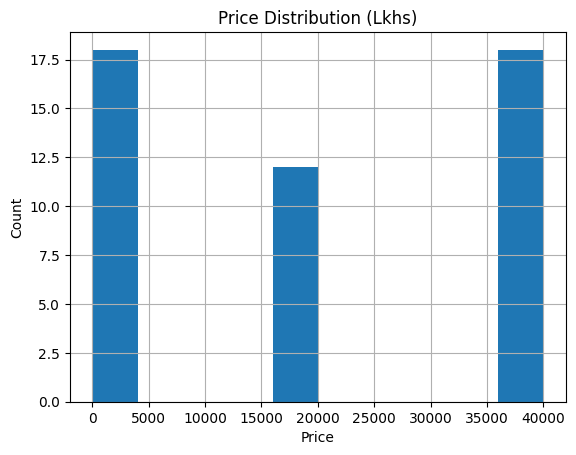

In [67]:
import matplotlib.pyplot as plt

df_lkhs["Price_Value"].hist()
plt.title("Price Distribution (Lkhs)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

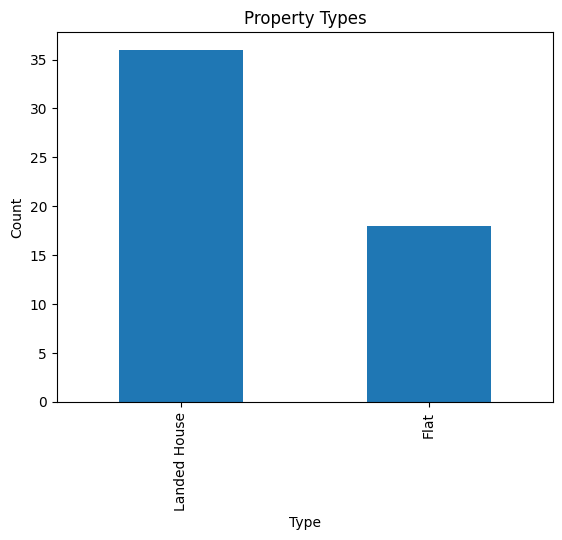

In [68]:
df["Type"].value_counts().plot(kind="bar")
plt.title("Property Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Questions:
* Which property type is most |common?
* Which listings have the highest price?
* Do flats have fewer bedrooms than landed houses?
* Are large-room properties always more expensive?

In [70]:
import numpy as np

df["Price_per_room"] = np.where(df["Rooms"] > 0, df["Price_Value"] / df["Rooms"], np.nan)
df["Price_per_bedroom"] = np.where(df["Bedrooms"] > 0, df["Price_Value"] / df["Bedrooms"], np.nan)

In [72]:

df["Price_Value"] = pd.to_numeric(df["Price_Value"], errors="coerce")
df["Rooms"] = pd.to_numeric(df["Rooms"], errors="coerce")
df["Bedrooms"] = pd.to_numeric(df["Bedrooms"], errors="coerce")

# Optional: remove rows with missing essential values
analysis_df = df.dropna(subset=["Type", "Price_Value"]).copy()

In [73]:
print("1. Which property type is most common?")
type_counts = analysis_df["Type"].value_counts()
print(type_counts)
print("\nMost common property type:", type_counts.idxmax())

1. Which property type is most common?
Type
Landed House    36
Flat            18
Name: count, dtype: int64

Most common property type: Landed House


In [76]:
# 2. Which listings have the highest price?

print("\n2. Which listings have the highest price?")

highest_price_listings = analysis_df.sort_values("Price_Value", ascending=False)[
    ["Price", "Currency", "Price_Value", "Address", "Type", "Rooms", "Bedrooms"]
].head(15)

print(highest_price_listings)


2. Which listings have the highest price?
           Price Currency  Price_Value  \
7   40000 Lkhs |     Lkhs      40000.0   
6   40000 Lkhs |     Lkhs      40000.0   
15  40000 Lkhs |     Lkhs      40000.0   
16  40000 Lkhs |     Lkhs      40000.0   
24  40000 Lkhs |     Lkhs      40000.0   
25  40000 Lkhs |     Lkhs      40000.0   
43  40000 Lkhs |     Lkhs      40000.0   
42  40000 Lkhs |     Lkhs      40000.0   
51  40000 Lkhs |     Lkhs      40000.0   
52  40000 Lkhs |     Lkhs      40000.0   
33  40000 Lkhs |     Lkhs      40000.0   
34  40000 Lkhs |     Lkhs      40000.0   
35  39800 Lkhs |     Lkhs      39800.0   
26  39800 Lkhs |     Lkhs      39800.0   
44  39800 Lkhs |     Lkhs      39800.0   

                                              Address          Type  Rooms  \
7      Bahan Township, U Wisara Road in Bahan, Yangon  Landed House     16   
6   Near U Wisara Road, North Dagon Township in Da...  Landed House     20   
15  Near U Wisara Road, North Dagon Township in Da

In [77]:
# 3. Do flats have fewer bedrooms than landed houses?

print("\n3. Do flats have fewer bedrooms than landed houses?")

bedroom_compare = analysis_df[analysis_df["Type"].isin(["Flat", "Landed House"])].groupby("Type")["Bedrooms"].mean()
print(bedroom_compare)

if "Flat" in bedroom_compare.index and "Landed House" in bedroom_compare.index:
    if bedroom_compare["Flat"] < bedroom_compare["Landed House"]:
        print("\nYes, flats have fewer bedrooms on average than landed houses.")
    elif bedroom_compare["Flat"] > bedroom_compare["Landed House"]:
        print("\nNo, flats have more bedrooms on average than landed houses.")
    else:
        print("\nFlats and landed houses have the same average number of bedrooms.")
else:
    print("\nNot enough data for both Flat and Landed House.")


3. Do flats have fewer bedrooms than landed houses?
Type
Flat            0.666667
Landed House    0.000000
Name: Bedrooms, dtype: float64

No, flats have more bedrooms on average than landed houses.


In [78]:
# 4. Are large-room properties always more expensive?

print("\n4. Are large-room properties always more expensive?")

# Average price by number of rooms
room_price_summary = analysis_df.groupby("Rooms")["Price_Value"].mean().sort_index()
print(room_price_summary)


4. Are large-room properties always more expensive?
Rooms
0     20000.0
3        40.0
4      5500.0
5        40.0
7        80.0
16    39900.0
20    40000.0
Name: Price_Value, dtype: float64


In [79]:
# Correlation between Rooms and Price_Value
corr = analysis_df[["Rooms", "Price_Value"]].corr().loc["Rooms", "Price_Value"]
print(f"\nCorrelation between Rooms and Price_Value: {corr:.2f}")

if corr > 0:
    print("There is a positive relationship: more rooms tend to have higher prices.")
else:
    print("There is not a positive relationship between more rooms and higher prices.")

# Check if price always increases as rooms increase
is_always_increasing = room_price_summary.is_monotonic_increasing

if is_always_increasing:
    print("Yes, based on average prices, larger-room properties are always more expensive.")
else:
    print("No, larger-room properties are not always more expensive.")


Correlation between Rooms and Price_Value: 0.74
There is a positive relationship: more rooms tend to have higher prices.
No, larger-room properties are not always more expensive.


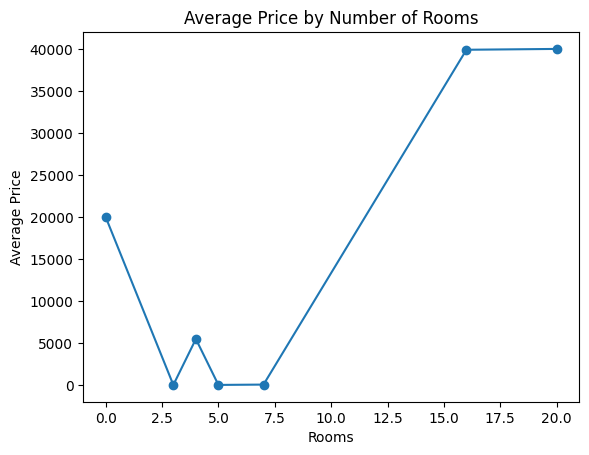

In [80]:
# Line chart
room_price_summary.plot(marker="o")
plt.title("Average Price by Number of Rooms")
plt.xlabel("Rooms")
plt.ylabel("Average Price")
plt.show()